# Cora Graph Neural Networks
Set up the Cora citation dataset and define baseline GNN models using the custom layers in `models.py`.

## Imports
Bring in PyTorch, PyG utilities, and the built-in GCN and GraphSAGE models from PyTorch Geometric.

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import add_self_loops, to_dense_adj
from torch_geometric.explain import Explainer, ModelConfig, GNNExplainer, PGExplainer
from torch_geometric.nn.models import GCN, GraphSAGE
from captum.attr import IntegratedGradients as CaptumIG
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
import networkx as nx
from typing import List, Optional 
import pandas as pd

/Users/hehvince/Desktop/FYP/FYP_Interpretable_Explanations/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Preparation
Load the Cora citation graph, move data to the chosen device, and build dense adjacency/features for the custom layer interface.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = Planetoid(root="./data/Planetoid", name="Cora")
data = dataset[0].to(device)

# Prepare edge index with self-loops plus convenience tensors
edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
data.edge_index = edge_index
adjacency = to_dense_adj(edge_index, max_num_nodes=data.num_nodes)[0].to(device)
features = data.x.to(device)
labels = data.y.to(device)

in_feats = features.size(-1)
num_classes = dataset.num_classes

# Provide a dummy batch vector so pooled models operate on the single graph
data.batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

cora_class_names = [
    "Case_Based",
    "Genetic_Algorithms",
    "Neural_Networks",
    "Probabilistic_Methods",
    "Reinforcement_Learning",
    "Rule_Learning",
    "Theory",
]
label_ids = sorted(labels.cpu().unique().tolist())
label_name_map = {idx: cora_class_names[idx] for idx in label_ids}

print(dataset)
print(f"Feature matrix: {features.shape}, adjacency: {adjacency.shape}")
print(f"Nodes: {data.num_nodes}, Features per node: {dataset.num_features}, Classes: {dataset.num_classes}")
print("Unique class labels:", label_name_map)

Cora()
Feature matrix: torch.Size([2708, 1433]), adjacency: torch.Size([2708, 2708])
Nodes: 2708, Features per node: 1433, Classes: 7
Unique class labels: {0: 'Case_Based', 1: 'Genetic_Algorithms', 2: 'Neural_Networks', 3: 'Probabilistic_Methods', 4: 'Reinforcement_Learning', 5: 'Rule_Learning', 6: 'Theory'}


## Instantiate and Inspect Models
Create GCN and GraphSAGE models using PyTorch Geometric's built-in implementations, run dry forwards, and confirm output dimensions.

In [3]:
gcn_model = GCN(
    in_channels=dataset.num_features,
    hidden_channels=64,
    num_layers=2,
    out_channels=dataset.num_classes,
    dropout=0.5
).to(device)

graphsage_model = GraphSAGE(
    in_channels=dataset.num_features,
    hidden_channels=64,
    num_layers=2,
    out_channels=dataset.num_classes,
    dropout=0.5
).to(device)

with torch.no_grad():
    gcn_model.eval()
    graphsage_model.eval()
    gcn_logits = gcn_model(data.x, data.edge_index)
    graphsage_logits = graphsage_model(data.x, data.edge_index)

print(f"GCN output shape: {gcn_logits.shape}")
print(f"GraphSAGE output shape: {graphsage_logits.shape}")

GCN output shape: torch.Size([2708, 7])
GraphSAGE output shape: torch.Size([2708, 7])


## Embedding Visualisation Helpers
Project model outputs into 2D via t-SNE for before/after comparisons.

In [4]:
def tsne_project(tensor: torch.Tensor, perplexity: float = 30.0, random_state: int = 42) -> torch.Tensor:
    embedding_np = tensor.detach().cpu().numpy()
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    coords = tsne.fit_transform(embedding_np)
    return torch.from_numpy(coords).float()

def plot_embeddings(coords_gcn, coords_sage, title_suffix: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    labels_cpu = labels.cpu()
    for ax, coords, model_name in zip(
        axes,
        (coords_gcn, coords_sage),
        ("GCN", "GraphSAGE"),
    ):
        ax.scatter(
            coords[:, 0],
            coords[:, 1],
            c=labels_cpu,
            cmap="tab10",
            s=10,
            alpha=0.8,
        )
        ax.set_title(f"{model_name} {title_suffix}")
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
    cmap = plt.cm.get_cmap("tab10", len(label_name_map))
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap(class_id), markersize=6)
        for class_id in sorted(label_name_map)
    ]
    axes[-1].legend(
        handles,
        [label_name_map[idx] for idx in sorted(label_name_map)],
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )
    plt.tight_layout()
    plt.show()

## Pre-Training Embedding Snapshot
Visualise random-initialised model outputs with t-SNE before any optimisation.

/var/folders/cx/t80f8k7j2h1b0cnx64j7nxg00000gn/T/ipykernel_16238/2766157793.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(label_name_map))


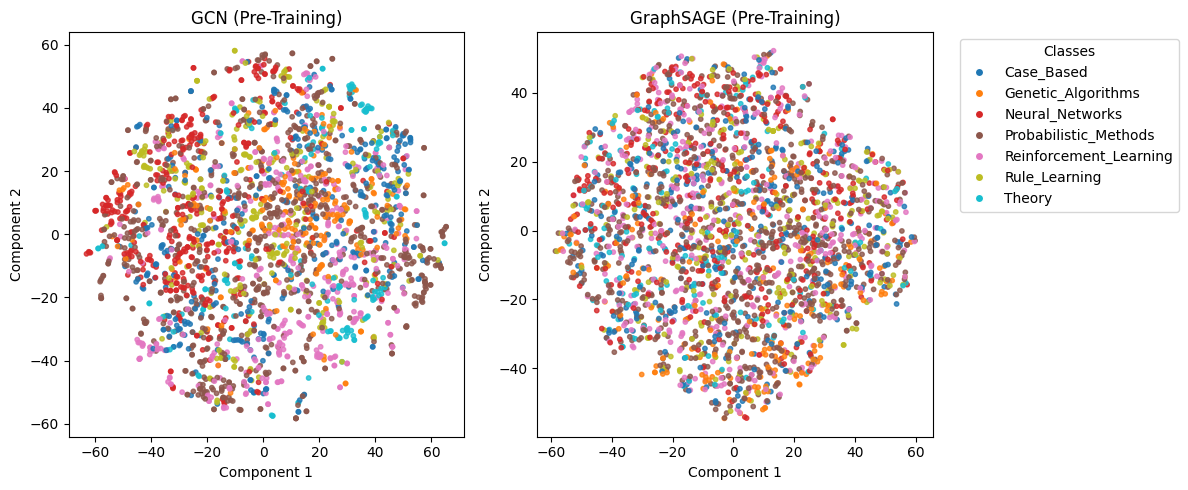

In [5]:
with torch.no_grad():
    gcn_model.eval()
    graphsage_model.eval()
    pre_gcn_logits = gcn_model(data.x, data.edge_index)
    pre_sage_logits = graphsage_model(data.x, data.edge_index)

pre_gcn_coords = tsne_project(pre_gcn_logits)
pre_sage_coords = tsne_project(pre_sage_logits)
plot_embeddings(pre_gcn_coords, pre_sage_coords, "(Pre-Training)")

## Training Utilities
Set up loss functions, optimizers, and helper routines to train and evaluate both models.

In [7]:
loss_fn = nn.CrossEntropyLoss()

train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask

# Increased weight_decay for GCN to reduce overfitting (5e-4 -> 5e-3)
# Reduced learning rate for more stable convergence (0.01 -> 0.005)
gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.005, weight_decay=5e-3)
graphsage_optimizer = torch.optim.Adam(graphsage_model.parameters(), lr=0.01, weight_decay=5e-4)

def train_gcn() -> tuple[float, float]:
    gcn_model.train()
    gcn_optimizer.zero_grad()
    logits = gcn_model(data.x, data.edge_index)
    loss = loss_fn(logits[train_mask], labels[train_mask])
    loss.backward()
    gcn_optimizer.step()
    preds = logits.argmax(dim=-1)
    train_acc = (preds[train_mask] == labels[train_mask]).float().mean().item()
    return loss.item(), train_acc

def train_graphsage() -> tuple[float, float]:
    graphsage_model.train()
    graphsage_optimizer.zero_grad()
    logits = graphsage_model(data.x, data.edge_index)
    loss = loss_fn(logits[train_mask], labels[train_mask])
    loss.backward()
    graphsage_optimizer.step()
    preds = logits.argmax(dim=-1)
    train_acc = (preds[train_mask] == labels[train_mask]).float().mean().item()
    return loss.item(), train_acc

@torch.no_grad()
def evaluate_gcn(mask: torch.Tensor):
    gcn_model.eval()
    logits = gcn_model(data.x, data.edge_index)
    preds = logits.argmax(dim=-1)
    loss = loss_fn(logits[mask], labels[mask])
    acc = (preds[mask] == labels[mask]).float().mean().item()
    return loss.item(), acc, preds

@torch.no_grad()
def evaluate_graphsage(mask: torch.Tensor):
    graphsage_model.eval()
    logits = graphsage_model(data.x, data.edge_index)
    preds = logits.argmax(dim=-1)
    loss = loss_fn(logits[mask], labels[mask])

    acc = (preds[mask] == labels[mask]).float().mean().item()    
    return loss.item(), acc, preds

## Train Models
Run a joint training loop and monitor validation loss/accuracy for both architectures.

In [8]:
# Early stopping for GCN to prevent overfitting
gcn_epochs = 1000
best_val_loss = float('inf')
patience = 100  # Stop if no improvement for 100 epochs
patience_counter = 0

for epoch in range(1, gcn_epochs + 1):
    gcn_loss, gcn_train_acc = train_gcn()
    gcn_val_loss, gcn_val_acc, _ = evaluate_gcn(val_mask)
    
    # Early stopping check
    if gcn_val_loss < best_val_loss:
        best_val_loss = gcn_val_loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if epoch == 1 or epoch % 20 == 0 or epoch == gcn_epochs:
        print(
            f"[GCN] Epoch {epoch:03d} | "
            f"train {gcn_loss:.4f} (acc {gcn_train_acc:.4f}) / "
            f"val {gcn_val_loss:.4f} (acc {gcn_val_acc:.4f}) | "
            f"best_val {best_val_loss:.4f}"
        )
    
    if patience_counter >= patience:
        print(f"[GCN] Early stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})")
        break

graphsage_epochs = 1000
for epoch in range(1, graphsage_epochs + 1):
    sage_loss, sage_train_acc = train_graphsage()
    if epoch == 1 or epoch % 20 == 0 or epoch == graphsage_epochs:
        sage_val_loss, sage_val_acc, _ = evaluate_graphsage(val_mask)
        print(
            f"[GraphSAGE] Epoch {epoch:03d} | "
            f"train {sage_loss:.4f} (acc {sage_train_acc:.4f}) / "
            f"val {sage_val_loss:.4f} (acc {sage_val_acc:.4f})"
        )

[GCN] Epoch 001 | train 1.9520 (acc 0.1643) / val 1.8856 (acc 0.5440) | best_val 1.8856
[GCN] Epoch 020 | train 0.2132 (acc 1.0000) / val 0.7947 (acc 0.7900) | best_val 0.7947
[GCN] Epoch 040 | train 0.1022 (acc 1.0000) / val 0.7324 (acc 0.7840) | best_val 0.7324
[GCN] Epoch 060 | train 0.1170 (acc 1.0000) / val 0.7291 (acc 0.7800) | best_val 0.7199
[GCN] Epoch 080 | train 0.0891 (acc 1.0000) / val 0.7087 (acc 0.7860) | best_val 0.7012
[GCN] Epoch 100 | train 0.0845 (acc 1.0000) / val 0.7068 (acc 0.7800) | best_val 0.7012
[GCN] Epoch 120 | train 0.0832 (acc 1.0000) / val 0.7051 (acc 0.7760) | best_val 0.6955
[GCN] Epoch 140 | train 0.0768 (acc 1.0000) / val 0.7067 (acc 0.7820) | best_val 0.6955
[GCN] Epoch 160 | train 0.0753 (acc 1.0000) / val 0.7199 (acc 0.7720) | best_val 0.6955
[GCN] Epoch 180 | train 0.0830 (acc 1.0000) / val 0.7001 (acc 0.7800) | best_val 0.6955
[GCN] Epoch 200 | train 0.0760 (acc 1.0000) / val 0.7097 (acc 0.7800) | best_val 0.6955
[GCN] Epoch 220 | train 0.0723 (

## Evaluate on Test Set
Measure final performance and compare a handful of predicted labels against the ground truth.

In [9]:
gcn_test_loss, gcn_test_acc, gcn_preds = evaluate_gcn(test_mask)
sage_test_loss, sage_test_acc, sage_preds = evaluate_graphsage(test_mask)

print(f"GCN test loss {gcn_test_loss:.4f}, accuracy {gcn_test_acc:.4f}")
print(f"GraphSAGE test loss {sage_test_loss:.4f}, accuracy {sage_test_acc:.4f}")

test_indices = test_mask.nonzero(as_tuple=False).view(-1)
sample_count = min(10, test_indices.numel())
sample_indices = test_indices[:sample_count]

if sample_count == 0:
    print("No test nodes available in the current split.")
else:
    print("\nSample predictions on test nodes:")
    for idx in sample_indices:
        idx_int = int(idx.item())
        true_label = int(labels[idx].item())
        gcn_label = int(gcn_preds[idx].item())
        sage_label = int(sage_preds[idx].item())
        print(
            f"Node {idx_int:4d} | True: {true_label} | "
            f"GCN: {gcn_label} | GraphSAGE: {sage_label}"
        )

GCN test loss 0.6215, accuracy 0.8080
GraphSAGE test loss 0.7950, accuracy 0.7660

Sample predictions on test nodes:
Node 1708 | True: 3 | GCN: 1 | GraphSAGE: 0
Node 1709 | True: 2 | GCN: 2 | GraphSAGE: 2
Node 1710 | True: 2 | GCN: 2 | GraphSAGE: 2
Node 1711 | True: 2 | GCN: 2 | GraphSAGE: 2
Node 1712 | True: 2 | GCN: 2 | GraphSAGE: 2
Node 1713 | True: 0 | GCN: 0 | GraphSAGE: 0
Node 1714 | True: 2 | GCN: 2 | GraphSAGE: 2
Node 1715 | True: 2 | GCN: 2 | GraphSAGE: 2
Node 1716 | True: 2 | GCN: 2 | GraphSAGE: 2
Node 1717 | True: 2 | GCN: 2 | GraphSAGE: 2


## GNN Explainer Interpretability
Use GNN Explainer to visualise influential subgraphs for sample predictions and quantify explanation quality.

In [11]:

def _normalize_node_mask(node_mask, x: torch.Tensor, node_idx: int) -> torch.Tensor:
    if node_mask is None:
        return torch.ones_like(x)
    if node_mask.dim() == 2:
        if node_mask.shape == x.shape:
            return node_mask
        if node_mask.size(0) == x.size(0) and node_mask.size(1) == 1:
            return node_mask.repeat(1, x.size(-1))
    if node_mask.dim() == 1:
        if node_mask.numel() == x.size(-1):
            expanded = torch.ones_like(x)
            expanded[node_idx] = node_mask
            return expanded
        if node_mask.numel() == x.size(0):
            return node_mask.unsqueeze(-1).repeat(1, x.size(-1))
    if node_mask.dim() == 2 and node_mask.size(1) == x.size(-1):
        return node_mask
    return torch.ones_like(x)

EXPLAINER_PARAMS = {
    "gnn_explainer_epochs": 300
    ,
    "gnn_stability_epochs": 200,
    "pg_explainer_epochs": 30,
    "pg_lr": 0.003,
    "pg_train_sample_size": 300,
    "ig_n_steps": 128,
    "ig_internal_batch_size": 1,
    "stability_runs": 7,
    "edge_selection_quantile": 0.92,
    "edge_selection_min_edges": 10,
}

def _build_target_tensor(node_idx: int, data, labels: torch.Tensor, model: torch.nn.Module) -> tuple[torch.Tensor, int]:
    """Build node-wise target tensor from model predictions and return class for node_idx."""
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        predicted_labels = logits.argmax(dim=-1).to(dtype=labels.dtype, device=labels.device)
        predicted_class = int(predicted_labels[node_idx].item())
    return predicted_labels, predicted_class

def _prepare_edge_subset(
    edge_index: torch.Tensor,
    edge_mask: torch.Tensor,
    selection: torch.Tensor,
    max_edges: Optional[int] = None,
    inverse: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Prepare edge subset based on selection. If inverse=True, selects edges NOT in selection."""
    if inverse:
        selected_idx = (~selection).nonzero(as_tuple=False).view(-1)
    else:
        selected_idx = selection.nonzero(as_tuple=False).view(-1)
    
    if selected_idx.numel() == 0:
        selected_idx = edge_mask.topk(1).indices
    if max_edges is not None and selected_idx.numel() > max_edges:
        mask_values = edge_mask[selected_idx]
        topk = mask_values.topk(max_edges).indices
        selected_idx = selected_idx[topk]
    sub_edge_index = edge_index[:, selected_idx]
    sub_edge_mask = edge_mask[selected_idx]
    return sub_edge_index, sub_edge_mask

def _plot_explanation(
    node_idx: int,
    edge_index: torch.Tensor,
    edge_mask: torch.Tensor,
    selection: torch.Tensor,
    ax: plt.Axes,
    max_edges: Optional[int] = 20,
):
    sub_edge_index, sub_edge_mask = _prepare_edge_subset(
        edge_index, edge_mask, selection, max_edges=max_edges, inverse=False
    )
    sub_edge_index = sub_edge_index.detach().cpu()
    sub_edge_mask = sub_edge_mask.detach().cpu()

    graph = nx.Graph()
    edges = sub_edge_index.t().tolist()
    weights = sub_edge_mask.tolist() if sub_edge_mask.numel() > 0 else []
    nodes = set()
    for idx, (src, dst) in enumerate(edges):
        weight = weights[idx] if idx < len(weights) else 0.0
        graph.add_edge(src, dst, weight=float(weight))
        nodes.add(src)
        nodes.add(dst)
    nodes.add(node_idx)
    graph.add_nodes_from(nodes)

    if node_idx not in graph:
        graph.add_node(node_idx)

    for node in graph.nodes():
        label_val = int(labels[node].item())
        graph.nodes[node]["label"] = label_name_map.get(label_val, str(label_val))

    pos = nx.spring_layout(graph, seed=42)
    node_colors = ["#ff7f0e" if node == node_idx else "#1f77b4" for node in graph.nodes()]

    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=300, alpha=0.9, ax=ax)
    if graph.number_of_edges() > 0:
        edge_weights = [max(float(data.get("weight", 0.0)), 0.0) for _, _, data in graph.edges(data=True)]
        w_min = min(edge_weights)
        w_max = max(edge_weights)
        if w_max - w_min < 1e-9:
            norm_vals = [0.5 for _ in edge_weights]
        else:
            norm_vals = [(w - w_min) / (w_max - w_min) for w in edge_weights]
        edge_colors = [plt.cm.Reds(v) for v in norm_vals]
        edge_widths = [1.5 + 2.5 * v for v in norm_vals]
        nx.draw_networkx_edges(graph, pos, edge_color=edge_colors, width=edge_widths, ax=ax)
    nx.draw_networkx_labels(
        graph, pos,
        labels={n: graph.nodes[n]["label"] for n in graph.nodes()},
        font_size=8, ax=ax,
    )
    ax.set_axis_off()

def run_gnn_explainer(model: torch.nn.Module, node_idx: int, data, epochs: Optional[int] = None):
    model.eval()
    epochs = EXPLAINER_PARAMS["gnn_explainer_epochs"] if epochs is None else epochs
    target_tensor, predicted_class = _build_target_tensor(node_idx, data, labels, model)
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=epochs),
        explanation_type="phenomenon",
        model_config=ModelConfig(
            mode="multiclass_classification",
            task_level="node",
            return_type="raw",
        ),
        node_mask_type="attributes",
        edge_mask_type="object",
    )
    explanation = explainer(data.x, data.edge_index, index=node_idx, target=target_tensor)
    edge_mask = explanation.edge_mask
    if edge_mask is None:
        edge_mask = torch.zeros(data.edge_index.size(1), device=data.edge_index.device)
    node_feat_mask = _normalize_node_mask(explanation.node_mask, data.x, node_idx).to(data.x.device)
    edge_mask = edge_mask.to(data.edge_index.device)
    return explainer, explanation, node_feat_mask, edge_mask, predicted_class

def run_pg_explainer(
    model: torch.nn.Module,
    node_idx: int,
    data,
    epochs: Optional[int] = None,
    lr: Optional[float] = None,
    train_sample_size: Optional[int] = None,
):
    """Run PGExplainer - a parameterized explainer that learns to explain."""
    model.eval()
    epochs = EXPLAINER_PARAMS["pg_explainer_epochs"] if epochs is None else epochs
    lr = EXPLAINER_PARAMS["pg_lr"] if lr is None else lr
    train_sample_size = EXPLAINER_PARAMS["pg_train_sample_size"] if train_sample_size is None else train_sample_size
    target_tensor, predicted_class = _build_target_tensor(node_idx, data, labels, model)
    explainer = Explainer(
        model=model,
        algorithm=PGExplainer(epochs=epochs, lr=lr),
        explanation_type="phenomenon",
        model_config=ModelConfig(
            mode="multiclass_classification",
            task_level="node",
            return_type="raw",
        ),
        node_mask_type=None,
        edge_mask_type="object",
    )
    train_indices = data.train_mask.nonzero(as_tuple=False).view(-1)
    import random
    sample_size = min(train_sample_size, train_indices.numel())
    sampled_indices = random.sample(train_indices.tolist(), sample_size)
    for epoch in range(epochs):
        for index in sampled_indices:
            loss = explainer.algorithm.train(
                epoch, model, data.x, data.edge_index, target=target_tensor, index=index
            )
    explanation = explainer(data.x, data.edge_index, index=node_idx, target=target_tensor)
    edge_mask = explanation.edge_mask
    if edge_mask is None:
        edge_mask = torch.zeros(data.edge_index.size(1), device=data.edge_index.device)
    node_feat_mask = torch.ones_like(data.x)
    edge_mask = edge_mask.to(data.edge_index.device)
    return explainer, explanation, node_feat_mask, edge_mask, predicted_class

def _derive_edge_mask_from_node_mask(node_mask: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
    """Derive edge importance from node-level attributions.
    For each edge (u, v), importance = (node_imp[u] + node_imp[v]) / 2.
    """
    if node_mask is None:
        return torch.zeros(edge_index.size(1), device=edge_index.device)
    if node_mask.dim() == 2:
        node_imp = node_mask.abs().norm(dim=1)
    else:
        node_imp = node_mask.abs()
    if node_imp.max() > 0:
        node_imp = node_imp / node_imp.max()
    src, dst = edge_index[0], edge_index[1]
    return ((node_imp[src] + node_imp[dst]) / 2.0).detach()

def run_integrated_gradients(model: torch.nn.Module, node_idx: int, data):
    """
    Run Integrated Gradients using Captum directly (bypassing CaptumExplainer).
    
    CaptumExplainer is incompatible with GCNConv because:
    1) GCNConv adds self-loops, changing edge_index size vs the edge mask
    2) Captum's batched IG slices edge_index along dim 0, corrupting [2,E] → [1,E]
    We avoid both issues by capturing edge_index in a closure.
    
    Returns: (None, explanation_dict, node_feat_mask, edge_mask, predicted_class)
    """
    model.eval()
    _, predicted_class = _build_target_tensor(node_idx, data, labels, model)
    
    x = data.x.clone()
    edge_index = data.edge_index  # captured in closure — Captum never touches it
    
    def forward_func(x_input):
        out = model(x_input.squeeze(0), edge_index)
        return out[node_idx].unsqueeze(0)  # [1, num_classes]
    
    ig = CaptumIG(forward_func)
    attributions = ig.attribute(
        x.unsqueeze(0),           # [1, num_nodes, num_features]
        target=predicted_class,   # scalar int
        internal_batch_size=EXPLAINER_PARAMS["ig_internal_batch_size"],
        n_steps=EXPLAINER_PARAMS["ig_n_steps"],
    )
    node_mask = attributions.squeeze(0).detach()  # [num_nodes, num_features]
    
    node_feat_mask = _normalize_node_mask(node_mask, data.x, node_idx).to(dtype=data.x.dtype, device=data.x.device)
    edge_mask = _derive_edge_mask_from_node_mask(node_mask, data.edge_index)
    edge_mask = edge_mask.to(dtype=data.x.dtype, device=data.edge_index.device)
    
    explanation = {"node_mask": node_mask, "edge_mask": edge_mask, "predicted_class": predicted_class}
    return None, explanation, node_feat_mask, edge_mask, predicted_class

def build_edge_selection(edge_mask: torch.Tensor) -> torch.Tensor:
    if edge_mask.numel() == 0:
        return torch.zeros_like(edge_mask, dtype=torch.bool)
    q = EXPLAINER_PARAMS["edge_selection_quantile"]
    min_edges = min(EXPLAINER_PARAMS["edge_selection_min_edges"], edge_mask.numel())
    threshold = torch.quantile(edge_mask, q)
    selection = (edge_mask >= threshold).to(torch.bool)
    if int(selection.sum().item()) < min_edges:
        top_idx = edge_mask.topk(min_edges).indices
        selection = torch.zeros_like(edge_mask, dtype=torch.bool)
        selection[top_idx] = True
    return selection

def compute_explanation_metrics(
    model: torch.nn.Module,
    data,
    node_idx: int,
    node_feat_mask: torch.Tensor,
    edge_mask: torch.Tensor,
    selection: torch.Tensor,
    target_class: int,
) -> dict:
    x, edge_index = data.x, data.edge_index
    true_class = int(labels[node_idx].item())
    is_correct = (target_class == true_class)

    with torch.no_grad():
        logits = model(x, edge_index)
        probs = logits.softmax(dim=-1)
        full_prob = float(probs[node_idx, target_class].item())

        inverse_node_feat_mask = 1.0 - node_feat_mask
        masked_x = x * inverse_node_feat_mask
        masked_edge_index, _ = _prepare_edge_subset(edge_index, edge_mask, selection, inverse=True)
        masked_logits = model(masked_x, masked_edge_index)
        masked_probs = masked_logits.softmax(dim=-1)
        masked_prob = float(masked_probs[node_idx, target_class].item())

    fidelity = masked_prob / (full_prob + 1e-9) if full_prob > 0 else float("nan")
    prob_drop = masked_prob - full_prob
    sparsity = 1.0 - float(selection.float().mean().item())
    edge_keep = float(selection.float().mean().item())

    return {
        "predicted_class": target_class,
        "true_class": true_class,
        "is_correct": is_correct,
        "full_prob": full_prob,
        "masked_prob": masked_prob,
        "fidelity": fidelity,
        "prob_drop": prob_drop,
        "sparsity": sparsity,
        "edge_fraction_kept": edge_keep,
    }

def estimate_stability(
    model: torch.nn.Module,
    data,
    node_idx: int,
    runs: Optional[int] = None,
) -> float:
    edge_masks: List[torch.Tensor] = []
    runs = EXPLAINER_PARAMS["stability_runs"] if runs is None else runs
    x, edge_index = data.x, data.edge_index
    cpu_state = torch.get_rng_state()
    cuda_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    try:
        for seed in range(runs):
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            target_tensor, _ = _build_target_tensor(node_idx, data, labels, model)
            explainer = Explainer(
                model=model,
                algorithm=GNNExplainer(epochs=EXPLAINER_PARAMS["gnn_stability_epochs"]),
                explanation_type="phenomenon",
                model_config=ModelConfig(
                    mode="multiclass_classification",
                    task_level="node",
                    return_type="raw",
                ),
                node_mask_type="attributes",
                edge_mask_type="object",
            )
            explanation = explainer(x, edge_index, index=node_idx, target=target_tensor)
            mask = explanation.edge_mask
            if mask is None:
                mask = torch.zeros(edge_index.size(1), device=x.device)
            edge_masks.append(mask.to(x.device))
    finally:
        torch.set_rng_state(cpu_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)

    if not edge_masks:
        return float("nan")

    stacked = torch.stack(edge_masks)
    return 1.0 - float(stacked.var(dim=0).mean().item())

def estimate_ig_stability(
    model: torch.nn.Module,
    node_idx: int,
    data,
    runs: Optional[int] = None,
) -> float:
    """Estimate stability of Integrated Gradients using Captum directly."""
    edge_masks: List[torch.Tensor] = []
    runs = EXPLAINER_PARAMS["stability_runs"] if runs is None else runs
    x, edge_index = data.x, data.edge_index
    cpu_state = torch.get_rng_state()
    cuda_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    
    try:
        for seed in range(runs):
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            
            _, predicted_class = _build_target_tensor(node_idx, data, labels, model)
            
            def forward_func(x_input, _ei=edge_index, _nidx=node_idx):
                out = model(x_input.squeeze(0), _ei)
                return out[_nidx].unsqueeze(0)
            
            ig = CaptumIG(forward_func)
            attributions = ig.attribute(
                x.unsqueeze(0), target=predicted_class,
                internal_batch_size=EXPLAINER_PARAMS["ig_internal_batch_size"], n_steps=EXPLAINER_PARAMS["ig_n_steps"],
            )
            node_mask = attributions.squeeze(0).detach()
            mask = _derive_edge_mask_from_node_mask(node_mask, edge_index)
            edge_masks.append(mask.to(x.device))
    finally:
        torch.set_rng_state(cpu_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)

    if not edge_masks:
        return float("nan")

    stacked = torch.stack(edge_masks)
    return 1.0 - float(stacked.var(dim=0).mean().item())


In [12]:
def explain_and_report(
    model: torch.nn.Module,
    model_name: str,
    explainer_name: str,
    explainer_fn,
    data,
    node_idx: int,
    runs: Optional[int] = None,
    max_edges: int = 20,
) -> dict:
    """Run explainer and generate metrics and visualization."""
    print(f"\nRunning {explainer_name} for {model_name}...")
    runs = EXPLAINER_PARAMS["stability_runs"] if runs is None else runs
    
    explainer, explanation, node_feat_mask, edge_mask, predicted_class = explainer_fn(model, node_idx, data)
    selection = build_edge_selection(edge_mask)
    metrics = compute_explanation_metrics(
        model,
        data,
        node_idx,
        node_feat_mask,
        edge_mask,
        selection,
        predicted_class,
    )
    metrics["stability"] = estimate_stability(model, data, node_idx, runs=runs)

    fig, ax = plt.subplots(figsize=(6, 6))
    _plot_explanation(
        node_idx=node_idx,
        edge_index=data.edge_index,
        edge_mask=edge_mask,
        selection=selection,
        ax=ax,
        max_edges=max_edges,
    )
    ax.set_title(f"{model_name} - {explainer_name}\n(node {node_idx})")
    plt.show()

    print(f"{model_name} - {explainer_name} metrics:")
    print(f"  predicted_class: {metrics['predicted_class']} ({label_name_map[metrics['predicted_class']]})")
    print(f"  true_class: {metrics['true_class']} ({label_name_map[metrics['true_class']]})")
    print(f"  is_correct: {metrics['is_correct']}")
    for key, value in metrics.items():
        if key not in ['predicted_class', 'true_class', 'is_correct']:
            print(f"  {key}: {value:.4f}")

    return {
        "explainer": explainer_name,
        "explainer_obj": explainer,
        "model": model_name,
        "explanation": explanation,
        "node_feat_mask": node_feat_mask,
        "edge_mask": edge_mask,
        "metrics": metrics,
    }

def compare_explainers(results: List[dict]) -> pd.DataFrame:
    """Create a comparison table of explainer metrics."""
    comparison_data = []
    for result in results:
        row = {
            "Model": result["model"],
            "Explainer": result["explainer"],
            **result["metrics"]
        }
        comparison_data.append(row)
    
    df = pd.DataFrame(comparison_data)
    # Reorder columns for better readability
    cols = ["Model", "Explainer", "is_correct", "fidelity", "prob_drop", "sparsity", 
            "edge_fraction_kept", "stability", "full_prob", "masked_prob"]
    df = df[[c for c in cols if c in df.columns]]
    return df

Explaining node 1713 with label 0 (Case_Based)

Running GNNExplainer for GCN...


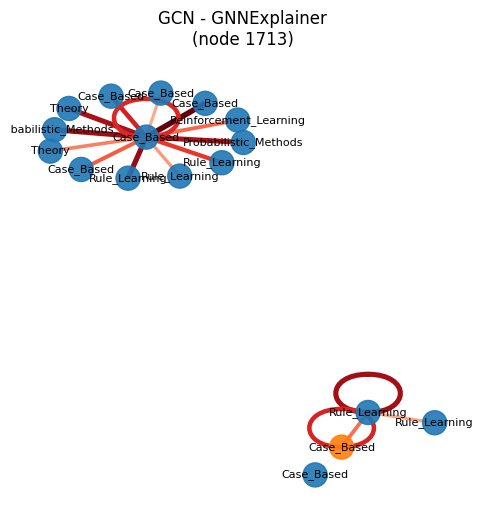

GCN - GNNExplainer metrics:
  predicted_class: 0 (Case_Based)
  true_class: 0 (Case_Based)
  is_correct: True
  full_prob: 0.3264
  masked_prob: 0.0076
  fidelity: 0.0234
  prob_drop: -0.3188
  sparsity: 0.0000
  edge_fraction_kept: 1.0000
  stability: 1.0000

Running PGExplainer for GCN...


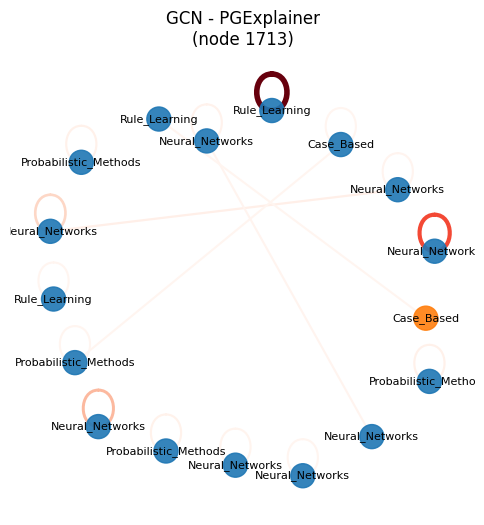

GCN - PGExplainer metrics:
  predicted_class: 0 (Case_Based)
  true_class: 0 (Case_Based)
  is_correct: True
  full_prob: 0.3264
  masked_prob: 0.0727
  fidelity: 0.2228
  prob_drop: -0.2537
  sparsity: 0.0000
  edge_fraction_kept: 1.0000
  stability: 1.0000

Running GNNExplainer for GraphSAGE...


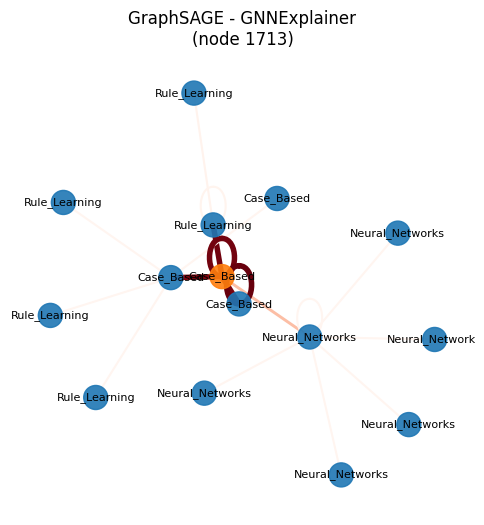

GraphSAGE - GNNExplainer metrics:
  predicted_class: 0 (Case_Based)
  true_class: 0 (Case_Based)
  is_correct: True
  full_prob: 0.7084
  masked_prob: 0.0731
  fidelity: 0.1033
  prob_drop: -0.6352
  sparsity: 0.0000
  edge_fraction_kept: 1.0000
  stability: 1.0000

Running PGExplainer for GraphSAGE...


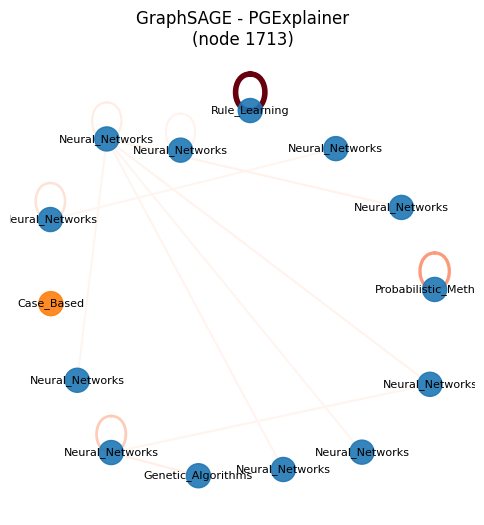

GraphSAGE - PGExplainer metrics:
  predicted_class: 0 (Case_Based)
  true_class: 0 (Case_Based)
  is_correct: True
  full_prob: 0.7084
  masked_prob: 0.1027
  fidelity: 0.1450
  prob_drop: -0.6057
  sparsity: 0.0000
  edge_fraction_kept: 1.0000
  stability: 1.0000

EXPLAINER COMPARISON
    Model    Explainer  is_correct  fidelity  prob_drop  sparsity  edge_fraction_kept  stability  full_prob  masked_prob
      GCN GNNExplainer        True  0.023418  -0.318770       0.0                 1.0   0.999983   0.326414     0.007644
      GCN  PGExplainer        True  0.222842  -0.253675       0.0                 1.0   0.999983   0.326414     0.072739
GraphSAGE GNNExplainer        True  0.103253  -0.635226       0.0                 1.0   1.000000   0.708367     0.073141
GraphSAGE  PGExplainer        True  0.144970  -0.605675       0.0                 1.0   1.000000   0.708367     0.102692

Metrics Guide:
  - fidelity: Lower is better (< 0.5 excellent, < 0.7 good)
  - prob_drop: More negative is 

In [13]:
test_nodes = test_mask.nonzero(as_tuple=False).view(-1)
if test_nodes.numel() == 0:
    raise ValueError("No test nodes available for explanation.")

# Choose sample node - modify this to select different nodes:
# Option 1: Pick by index (0 = first test node, 1 = second, etc.)
sample_idx = 5  # Change this number to select different test nodes

# Option 2: Uncomment to pick a random test node
# import random
# sample_idx = random.randint(0, test_nodes.numel() - 1)

# Option 3: Uncomment to use a specific node ID directly (if you know it)
# sample_node = 123  # Replace with specific node ID

sample_node = int(test_nodes[sample_idx].item())
print(f"Explaining node {sample_node} with label {int(labels[sample_node].item())} ({label_name_map[int(labels[sample_node].item())]})")

# Run all explainers for both models
results = []

# GCN with explainers
results.append(explain_and_report(gcn_model, "GCN", "GNNExplainer", run_gnn_explainer, data, sample_node))
results.append(explain_and_report(gcn_model, "GCN", "PGExplainer", run_pg_explainer, data, sample_node))

# GraphSAGE with explainers
results.append(explain_and_report(graphsage_model, "GraphSAGE", "GNNExplainer", run_gnn_explainer, data, sample_node))
results.append(explain_and_report(graphsage_model, "GraphSAGE", "PGExplainer", run_pg_explainer, data, sample_node))

# Create comparison table
comparison_df = compare_explainers(results)
print("\n" + "="*80)
print("EXPLAINER COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("\nMetrics Guide:")
print("  - fidelity: Lower is better (< 0.5 excellent, < 0.7 good)")
print("  - prob_drop: More negative is better (shows prediction degradation)")
print("  - sparsity: Higher is better (more compact explanation)")
print("  - stability: Higher is better (closer to 1.0 = more consistent)")


## Integrated Gradients Explanation
Use Integrated Gradients via CaptumExplainer to compute gradients-based importance scores, then compare all three explainers (GNNExplainer, PGExplainer, Integrated Gradients) using consistent metrics.

Running Integrated Gradients on node 1713 ...
(Computing gradient-based attributions via Captum directly...)

  → GCN


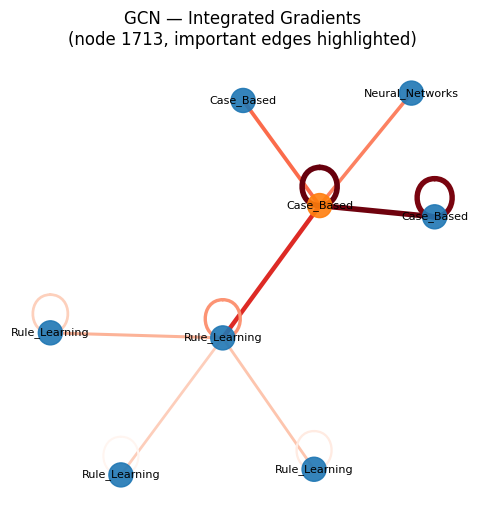

    Predicted: 0 (Case_Based) | True: 0 (Case_Based) | CORRECT
    Fidelity=0.3809  Prob_drop=-0.2021  Sparsity=0.9199  Stability=1.0000
  → GraphSAGE


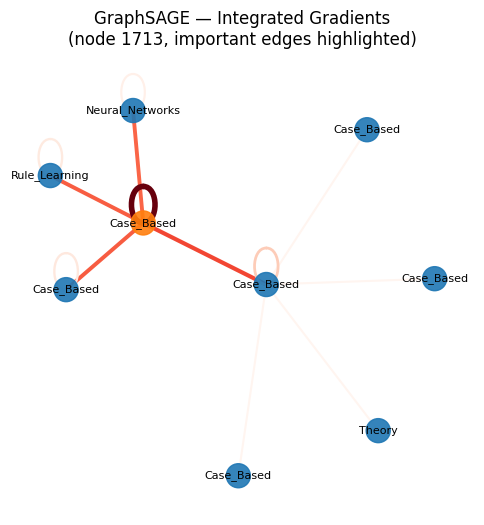

    Predicted: 0 (Case_Based) | True: 0 (Case_Based) | CORRECT
    Fidelity=0.1216  Prob_drop=-0.6222  Sparsity=0.9199  Stability=1.0000


In [14]:

# ── Integrated Gradients explanation for both models ──────────────────────────
print(f"Running Integrated Gradients on node {sample_node} ...")
print("(Computing gradient-based attributions via Captum directly...)\n")

ig_results = {}
for model_obj, model_name in [(gcn_model, "GCN"), (graphsage_model, "GraphSAGE")]:
    print(f"  → {model_name}")
    _, ig_explanation, node_feat_mask_ig, edge_mask_ig, pred_class_ig = run_integrated_gradients(
        model_obj, sample_node, data
    )
    selection_ig = build_edge_selection(edge_mask_ig)

    fig, ax = plt.subplots(figsize=(6, 6))
    _plot_explanation(sample_node, data.edge_index, edge_mask_ig, selection_ig, ax)
    ax.set_title(f"{model_name} — Integrated Gradients\n(node {sample_node}, important edges highlighted)")
    plt.show()

    ig_metrics = compute_explanation_metrics(
        model_obj, data, sample_node,
        node_feat_mask_ig, edge_mask_ig, selection_ig, pred_class_ig
    )
    ig_stability = estimate_ig_stability(model_obj, sample_node, data, runs=EXPLAINER_PARAMS["stability_runs"])
    ig_metrics["stability"] = ig_stability

    ig_results[model_name] = {
        "explanation":    ig_explanation,
        "edge_mask":      edge_mask_ig,
        "node_feat_mask": node_feat_mask_ig,
        "pred_class":     pred_class_ig,
        "model_obj":      model_obj,
        "metrics":        ig_metrics,
    }
    correct_str = "CORRECT" if ig_metrics["is_correct"] else "INCORRECT"
    print(f"    Predicted: {ig_metrics['predicted_class']} ({label_name_map[ig_metrics['predicted_class']]}) | "
          f"True: {ig_metrics['true_class']} ({label_name_map[ig_metrics['true_class']]}) | {correct_str}")
    print(f"    Fidelity={ig_metrics['fidelity']:.4f}  "
          f"Prob_drop={ig_metrics['prob_drop']:.4f}  "
          f"Sparsity={ig_metrics['sparsity']:.4f}  "
          f"Stability={ig_stability:.4f}")

## Unified Explainer Comparison
Merge results from GNNExplainer / PGExplainer and Integrated Gradients into a single comparison table.

In [15]:
# ── Build unified comparison from cell 21 (results) and cell 23 (ig_results) ──
unified_rows = []

# GNNExplainer & PGExplainer metrics from cell 21's `results` list
for r in results:
    m = r["metrics"]
    unified_rows.append({
        "Model":      r["model"],
        "Explainer":  r["explainer"],
        "Predicted":  m["predicted_class"],
        "True":       m["true_class"],
        "Correct":    m["is_correct"],
        "Fidelity":   m["fidelity"],
        "Prob Drop":  m["prob_drop"],
        "Sparsity":   m["sparsity"],
        "Edge Kept":  m["edge_fraction_kept"],
        "Stability":  m["stability"],
    })

# Integrated Gradients metrics from cell 23's `ig_results` dict
for model_name, ig_data in ig_results.items():
    m = ig_data["metrics"]
    unified_rows.append({
        "Model":      model_name,
        "Explainer":  "IntegratedGradients",
        "Predicted":  m["predicted_class"],
        "True":       m["true_class"],
        "Correct":    m["is_correct"],
        "Fidelity":   m["fidelity"],
        "Prob Drop":  m["prob_drop"],
        "Sparsity":   m["sparsity"],
        "Edge Kept":  m["edge_fraction_kept"],
        "Stability":  m["stability"],
    })

unified_df = (
    pd.DataFrame(unified_rows)
    .sort_values(["Model", "Explainer"])
    .reset_index(drop=True)
)

print("=" * 90)
print("UNIFIED METRICS — GNNExplainer | PGExplainer | IntegratedGradients")
print("=" * 90)
print(unified_df.to_string(index=False))
print("\nMetrics Guide:")
print("  Fidelity  : Lower → removing explanation degrades prediction more (< 0.5 excellent)")
print("  Prob Drop : More negative → stronger prediction degradation when explanation removed")
print("  Sparsity  : Higher → more compact explanation (fewer edges kept)")
print("  Edge Kept : Fraction of edges retained in the explanation subgraph")
print("  Stability : Higher → explanation is consistent across runs (closer to 1.0)")
print("\nNote: IG edge importance is derived from node feature attributions via Captum.")

UNIFIED METRICS — GNNExplainer | PGExplainer | IntegratedGradients
    Model           Explainer  Predicted  True  Correct  Fidelity  Prob Drop  Sparsity  Edge Kept  Stability
      GCN        GNNExplainer          0     0     True  0.023418  -0.318770  0.000000   1.000000   0.999983
      GCN IntegratedGradients          0     0     True  0.380875  -0.202091  0.919934   0.080066   1.000000
      GCN         PGExplainer          0     0     True  0.222842  -0.253675  0.000000   1.000000   0.999983
GraphSAGE        GNNExplainer          0     0     True  0.103253  -0.635226  0.000000   1.000000   1.000000
GraphSAGE IntegratedGradients          0     0     True  0.121624  -0.622213  0.919934   0.080066   1.000000
GraphSAGE         PGExplainer          0     0     True  0.144970  -0.605675  0.000000   1.000000   1.000000

Metrics Guide:
  Fidelity  : Lower → removing explanation degrades prediction more (< 0.5 excellent)
  Prob Drop : More negative → stronger prediction degradation when e

## Post-Training Embedding Snapshot
Repeat the projection with t-SNE after optimisation to show class separation.

/var/folders/cx/t80f8k7j2h1b0cnx64j7nxg00000gn/T/ipykernel_16238/2766157793.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(label_name_map))


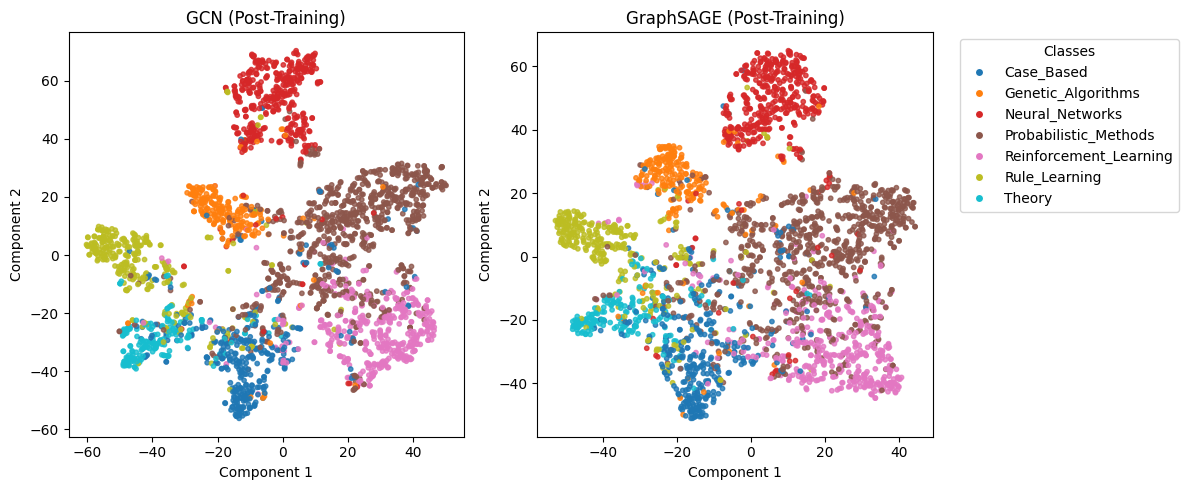

In [16]:
with torch.no_grad():
    gcn_model.eval()
    graphsage_model.eval()
    post_gcn_logits = gcn_model(data.x, data.edge_index)
    post_sage_logits = graphsage_model(data.x, data.edge_index)

post_gcn_coords = tsne_project(post_gcn_logits)
post_sage_coords = tsne_project(post_sage_logits)
plot_embeddings(post_gcn_coords, post_sage_coords, "(Post-Training)")

## Parameter Summary (Models and Explainers)

This section records the current hyperparameters used in the notebook after explainer tuning.

### Models
- **GCN**: `in_channels=dataset.num_features`, `hidden_channels=64`, `num_layers=2`, `out_channels=dataset.num_classes`, `dropout=0.5`
- **GraphSAGE**: `in_channels=dataset.num_features`, `hidden_channels=64`, `num_layers=2`, `out_channels=dataset.num_classes`, `dropout=0.5`

### Training
- **Loss**: `CrossEntropyLoss`
- **GCN optimizer**: `Adam(lr=0.005, weight_decay=5e-3)`
- **GraphSAGE optimizer**: `Adam(lr=0.01, weight_decay=5e-4)`
- **GCN epochs**: up to `1000` with early stopping (`patience=100`)
- **GraphSAGE epochs**: `1000`

### Explainers (Optimized v3 Defaults)
- **GNNExplainer**: `epochs=300`
- **GNNExplainer stability runs**: `runs=7`, each with `epochs=200`
- **PGExplainer**: `epochs=30`, `lr=0.003`, train sample size up to `300` nodes/epoch
- **Integrated Gradients (Captum)**: `n_steps=128`, `internal_batch_size=1`, stability `runs=7`
- **Edge selection rule**: top quantile threshold (`q=0.92`) with minimum kept edges `10`

### Notes
- Explainer targets are built from **model predictions for all nodes** (fixes a previous issue where one class target was reused during PGExplainer training).
- Main reported metrics: `fidelity`, `prob_drop`, `sparsity`, `edge_fraction_kept`, `stability`.